# Comprensión y EDA - Avance #1 (V1.0.1)

Análisis exploratorio de la base de datos de créditos.

**Dataset**: Base_de_datos.csv (datos de préstamos, variable objetivo: Pago_atiempo (1 = a tiempo, 0 = no).

**Secciones**:
1. Exploración inicial de datos (descripción, caracterización, nulos, unificar nulos, eliminar irrelevantes, corregir tipos).
2. Exploración de datos y descripción (EDA):
   - Análisis univariable (describe, histograma, boxplot, countplot, estadísticas, distribución).
   - Análisis bivariable (vs Pago_atiempo, gráficos, comentarios).
   - Análisis multivariable (pairplot, correlación, tablas cruzadas, dispersión).
3. Insights: comentarios, interpretaciones, reglas de validación, transformaciones posibles, atributos derivados.

In [2]:
import pandas as pd  
import numpy as np   
import matplotlib.pyplot as plt  
import seaborn as sns  
from scipy import stats  

In [3]:
df = pd.read_csv('../Base_de_datos.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

In [45]:
pd.set_option('display.max_columns', None)
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,12/21/24 11:31,3692160,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,4/22/25 9:47,840000,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,1/8/26 12:22,5974028,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,8/4/25 12:04,1671240,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,4/26/25 11:24,2781636,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [46]:
print("Columnas:", df.columns.tolist())

Columnas: ['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'Pago_atiempo']


In [47]:
numericas = ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']  # Numéricas/continuas
categoricas = ['tipo_laboral']
ordinales = ['tipo_credito', 'tendencia_ingresos']
fechas = ['fecha_prestamo']
objetivo = 'Pago_atiempo'

print("\nVariables numéricas:", numericas)
print("Variables categóricas:", categoricas)
print("Variables ordinales:", ordinales)
print("Variables de fecha:", fechas)
print("Variable objetivo:", objetivo)


Variables numéricas: ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']
Variables categóricas: ['tipo_laboral']
Variables ordinales: ['tipo_credito', 'tendencia_ingresos']
Variables de fecha: ['fecha_prestamo']
Variable objetivo: Pago_atiempo


In [48]:
# Revisión de nulos
print("Nulos por columna:")
print(df.isnull().sum())

# Unificar nulos (reemplazar valores como '', 'None')
df.replace(['', 'None', 'NULL'], np.nan, inplace=True)

# Comentario
print("\nInterpretación: Si hay nulos, se unificaron a NaN. Por ej, si 'saldo_mora' tiene muchos nulos, podría indicar clientes sin mora.")

# Porcentaje de nulos después
print("Porcentaje de nulos después:")
print((df.isnull().sum() / len(df) * 100).round(2))

Nulos por columna:
tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
Pago_atiempo                        0
dtype: int64

Interpretación: Si hay nulos, se unificaron a NaN. Por ej, si 'saldo_mora' tiene muchos nulos

In [49]:
#tratamiento de nulos numericos con la mediana
for col in numericas:
    if col in df.columns:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10763 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

In [51]:
df.shape

(10763, 23)

In [52]:
col = 'tendencia_ingresos'

if col in df.columns:
    # Si es categórica, agregamos la categoría primero
    if df[col].dtype.name == 'category':
        df[col] = df[col].cat.add_categories(['Sin dato'])

    nulos_antes = df[col].isnull().sum()
    filas_totales = len(df)
    pct_nulos = round(nulos_antes / filas_totales * 100, 2)

    print(f"Columna '{col}': {nulos_antes} nulos ({pct_nulos}% de {filas_totales} filas)")

    # Imputación
    df[col] = df[col].fillna('Sin dato')

    # Verificación
    print("\nDistribución después de imputación:")
    print(df[col].value_counts(dropna=False))


Columna 'tendencia_ingresos': 2932 nulos (27.24% de 10763 filas)

Distribución después de imputación:
tendencia_ingresos
Creciente      5294
Sin dato       2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1

In [53]:
df[col].dtype


<StringDtype(storage='python', na_value=nan)>

In [54]:
df[col].unique()

<StringArray>
[    'Estable',   'Creciente',    'Sin dato', 'Decreciente',        '8315',
           '0',      '158042',        '3978',        '9147',      '168750',
      '-28589',     '1000000',     '-566272',       '24702',       '31837',
      '122727',      '417087',        '9090',      '173031',      '-70715',
     '-435177',     '-702927',       '-4105',       '54683',       '22832',
      '209090',        '5697',       '10808',        '-288',     '-164315',
     '2029000',       '17181',       '15245',       '82657',       '52862',
     '1817052',       '75761',      '146918',     '1123000',       '15090',
     '4250635',       '22363',     '-101368',       '86286',       '65988',
       '77975',     '-224714']
Length: 47, dtype: str

In [55]:
print(f"Distribución ORIGINAL de {col} ANTES de limpiar:")
print(df[col].value_counts(dropna=False).head(15))

Distribución ORIGINAL de tendencia_ingresos ANTES de limpiar:
tendencia_ingresos
Creciente      5294
Sin dato       2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
Name: count, dtype: int64


In [56]:
categorias_validas = {
    'Creciente', 'Estable', 'Decreciente', 
    'Sin dato', 'Desconocido', 'Otro'   # agregamos 'Otro' para lo raro
}

In [57]:
# Convertimos TODO lo que NO esté en categorías válidas a 'Sin dato'
df[col] = df[col].apply(lambda x: x if x in categorias_validas else 'Sin dato')

In [58]:
df[col].unique()

<StringArray>
['Estable', 'Creciente', 'Sin dato', 'Decreciente']
Length: 4, dtype: str

In [59]:
df[col] = df[col].fillna('Sin dato')

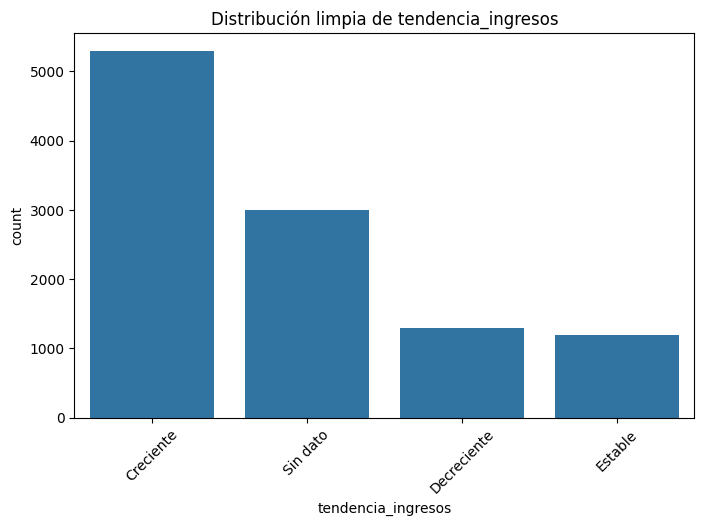

In [60]:

# Gráfico limpio
plt.figure(figsize=(8, 5))
sns.countplot(x=df[col], order=df[col].value_counts().index)
plt.title(f'Distribución limpia de {col}')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==============================================
# eda_check.py - Diagnóstico de Datos Crudos
# ==============================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga
print("--- 1. CARGA DE DATOS ---")
try:
    df = pd.read_csv('Base_de_datos.csv', encoding='latin-1')
    print("✔ Archivo cargado correctamente.")
    print(f"Dimensiones: {df.shape}")
except Exception as e:
    print(f"❌ Error cargando archivo: {e}")
    exit()

# 2. Tipos de Datos y Nulos
print("\n--- 2. INFO GENERAL ---")
print(df.info())

# 3. Análisis del Target
print("\n--- 3. BALANCE DEL TARGET (Pago_atiempo) ---")
if 'Pago_atiempo' in df.columns:
    print(df['Pago_atiempo'].value_counts(normalize=True))
    print(f"Nulos en Target: {df['Pago_atiempo'].isnull().sum()}")
else:
    print("❌ NO SE ENCONTRÓ LA COLUMNA 'Pago_atiempo'")

# 4. Análisis de Columnas Problemáticas (Categoricas)
print("\n--- 4. REVISIÓN DE CATEGÓRICAS SUCIAS ---")

cols_problema = ['tipo_credito', 'tendencia_ingresos', 'tipo_laboral']
for col in cols_problema:
    if col in df.columns:
        print(f"\n>>> Valores únicos en '{col}' (Top 20):")
        print(df[col].unique()[:20]) # Mostramos los primeros 20 para ver basura
        print(f"Tipo de dato detectado: {df[col].dtype}")
    else:
        print(f"Columna {col} no encontrada.")

# 5. Análisis de Numéricas (Outliers)
print("\n--- 5. ESTADÍSTICAS DE NUMÉRICAS (Detectando Outliers) ---")
cols_num = ['salario_cliente', 'cuota_pactada', 'total_otros_prestamos', 'capital_prestado']
print(df[cols_num].describe().apply(lambda s: s.apply('{0:.2f}'.format)))

# 6. Correlaciones Rápidas (Para ver si algo sirve desde ya)
print("\n--- 6. CORRELACIÓN CON TARGET ---")
# Filtramos solo numéricas
df_num = df.select_dtypes(include=[np.number])
if 'Pago_atiempo' in df_num.columns:
    corr = df_num.corr()['Pago_atiempo'].sort_values(ascending=False)
    print(corr)

--- 1. CARGA DE DATOS ---
❌ Error cargando archivo: [Errno 2] No such file or directory: 'Base_de_datos.csv'

--- 2. INFO GENERAL ---
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-nu

: 

--- 2. ANÁLISIS DE PERCENTILES (Cazando Outliers) ---
                                   min        50%         95%         99%  \
edad_cliente                        19         42          65         122   
plazo_meses                          2         10          24          36   
cant_creditosvigentes                0          5          13          19   
huella_consulta                      0          4          10          15   
salario_cliente                      0  3,000,000  10,000,000  39,553,562   
total_otros_prestamos                0  1,000,000   4,798,900  17,946,060   
capital_prestado               360,000  1,921,920   5,938,828   8,881,110   
cuota_pactada                   23,944    182,863     610,395   1,114,004   
puntaje_datacredito                 -7        791         873         900   
promedio_ingresos_datacredito        0  1,204,496   5,972,734  10,799,234   

                                          max  
edad_cliente                              123  
pl

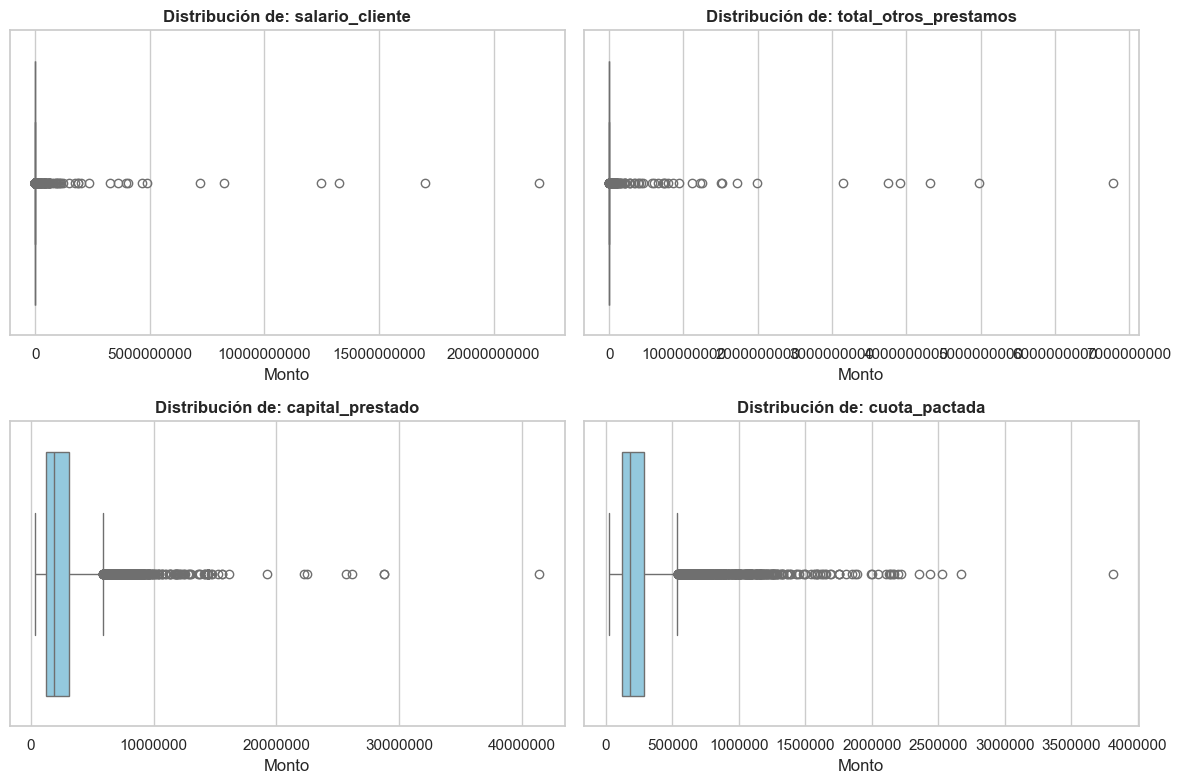

In [4]:
num_cols = [
    'edad_cliente', 'plazo_meses', 'cant_creditosvigentes', 'huella_consulta',
    'salario_cliente', 'total_otros_prestamos', 'capital_prestado', 'cuota_pactada',
    'puntaje_datacredito', 'promedio_ingresos_datacredito'
]

# Filtramos solo las columnas que realmente existen en el df
num_cols = [col for col in num_cols if col in df.columns]

print("--- 2. ANÁLISIS DE PERCENTILES (Cazando Outliers) ---")
# Calculamos percentiles clave: el salto del 99% al Max nos dice si hay outliers ridículos
percentiles = [.01, .25, .50, .75, .95, .99]
desc = df[num_cols].describe(percentiles=percentiles).T

# Formateamos para que los números grandes se lean fácil (con separador de miles)
tabla_outliers = desc[['min', '50%', '95%', '99%', 'max']].apply(lambda x: x.apply('{:,.0f}'.format))
print(tabla_outliers)

print("\n--- 3. REVISIÓN DE CERO ABSOLUTO ---")
# A veces tener "0" en salario o en cuota es un error de digitación
for col in ['salario_cliente', 'cuota_pactada', 'capital_prestado']:
    if col in df.columns:
        ceros = (df[col] == 0).sum()
        print(f"Registros con {col} = 0 : {ceros} ({(ceros/len(df))*100:.2f}%)")

print("\n--- 4. GENERANDO GRÁFICOS (Boxplots) ---")
# Vamos a graficar solo las variables de dinero, que suelen ser las más problemáticas
monetary_cols = ['salario_cliente', 'total_otros_prestamos', 'capital_prestado', 'cuota_pactada']
monetary_cols = [col for col in monetary_cols if col in df.columns]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

for i, col in enumerate(monetary_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Distribución de: {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Monto')
    # Evitar notación científica (las "e") en los ejes
    plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
print("⏳ Mostrando gráficos... (Cierra la ventana del gráfico para terminar el script)")
plt.show()